In [1]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import imgaug as ia
import imgaug.augmenters as iaa
import pickle
import json
from tqdm import tqdm
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.svm import SVC

ia.seed(1)

In [2]:
seq = iaa.Sequential([
    iaa.Fliplr(0.5), # horizontal flips
    iaa.Crop(percent=(0, 0.1)), # random crops
    # Small gaussian blur with random sigma between 0 and 0.5.
    # But we only blur about 50% of all images.
    iaa.Sometimes(
        0.5,
        iaa.GaussianBlur(sigma=(0, 0.5))
    ),
    # Strengthen or weaken the contrast in each image.
    iaa.LinearContrast((0.75, 1.5)),
    # Add gaussian noise.
    # For 50% of all images, we sample the noise once per pixel.
    # For the other 50% of all images, we sample the noise per pixel AND
    # channel. This can change the color (not only brightness) of the
    # pixels.
    iaa.AdditiveGaussianNoise(loc=0, scale=(0.0, 0.05*255), per_channel=0.5),
    # Make some images brighter and some darker.
    # In 20% of all cases, we sample the multiplier once per channel,
    # which can end up changing the color of the images.
    iaa.Multiply((0.8, 1.2), per_channel=0.2),
    # Apply affine transformations to each image.
    # Scale/zoom them, translate/move them, rotate them and shear them.
    iaa.Affine(
        scale={"x": (0.8, 1.2), "y": (0.8, 1.2)},
        translate_percent={"x": (-0.1, 0.1), "y": (-0.1, 0.1)},
        rotate=(-10, 10),
        shear=(-4, 4)
    )
], random_order=True) # apply augmenters in random order

In [5]:
path ="samples"
typ = 'train'

imgs = os.listdir(path)

labels = [f.strip('.jpg') for f in imgs]
labels = [l for l in labels if l != 'files.txt']
print(labels)

if not os.path.isdir(f'{typ}'):
        os.mkdir(f'{typ}')

['15', '8', '13', '19', '17', '24', '3', '25', '11', '23', '20', '1', '18', '7', '22', '14', '9', '5', '16', '21', '6', '2', '12', '10', '4', '26']


In [57]:
N = 2000
dim = 227
        
for label in labels:
   
    img = cv2.imread(os.path.join(path,f'{label}.jpg'),0)
    # resize image
    img = cv2.resize(img,(dim,dim), interpolation = cv2.INTER_AREA)
    images = np.array([ img for _ in range(N)],dtype=np.uint8)
    
    images_aug = seq(images=images)

    if not os.path.isdir(f'{typ}/{label}'):
        os.mkdir(f'{typ}/{label}')

    for i in range(N):
        cv2.imwrite(f'{typ}/{label}/{label}_{i}.jpg',images_aug[i])

In [8]:
path ="samples"
typ = 'test'

if not os.path.isdir(f'{typ}'):
        os.mkdir(f'{typ}')

In [9]:
N = 1000
dim=227

for label in labels:
    
    img = cv2.imread(os.path.join(path,f'{label}.jpg'),0)
    # resize image
    img = cv2.resize(img,(dim,dim), interpolation = cv2.INTER_AREA)
    images = np.array([ img for _ in range(N)],dtype=np.uint8)
    
    images_aug = seq(images=images)

    if not os.path.isdir(f'{typ}/{label}'):
        os.mkdir(f'{typ}/{label}')

    for i in range(N):
        cv2.imwrite(f'{typ}/{label}/{label}_{i}.jpg',images_aug[i])

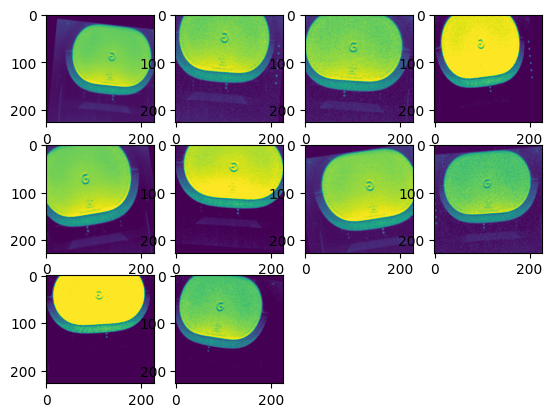

In [10]:
num = 10
col=4
imgs = list(np.random.choice(len(images_aug),num))
for i in range(num):
    plt.subplot(num/col if num%col==0 else int(num/col)+1,col,i+1)
    plt.imshow(images_aug[imgs[i]])

In [11]:
with open('dicts.json','r') as f:
    dicts = json.load(f)
dicts

{'1': {'device': 'Google Nest Learning Thermostat (Black)', 'model': 'H1HB1J'},
 '2': {'device': 'Google Nest Hello Doorbell', 'model': 'A0077'},
 '3': {'device': 'Chromecast Ultra (2016)', 'model': 'G2RNL'},
 '4': {'device': 'Google Wifi (1 pk)', 'model': 'H2D'},
 '5': {'device': 'Google Nest Cam Outdoor', 'model': 'G3AL9'},
 '6': {'device': 'Google Nest Cam IQ Indoor', 'model': 'G9Q9T'},
 '7': {'device': 'Chromecast Black', 'model': 'NC2-6A5 BLACK'},
 '8': {'device': 'Google Nest Cam IQ Outdoor', 'model': 'KT1UM9'},
 '9': {'device': 'Google Nest Wifi Router', 'model': 'G6ZUC'},
 '10': {'device': 'Google Home Mini', 'model': 'H2C'},
 '11': {'device': 'Google TV Remote', 'model': 'G9N9N'},
 '12': {'device': 'Google Nest Protect smoke alarm', 'model': 'NEST-4895'},
 '13': {'device': 'Google Home', 'model': 'HOME'},
 '14': {'device': 'Google Chromecast White', 'model': 'NC2-6A5 BWHITE'},
 '15': {'device': 'Google Nest Connect range extender', 'model': 'A0078'},
 '16': {'device': 'Google 

In [12]:
dic ={}
for d in dicts:
    dic[int(d)] = dicts[d]['device']
dic

{1: 'Google Nest Learning Thermostat (Black)',
 2: 'Google Nest Hello Doorbell',
 3: 'Chromecast Ultra (2016)',
 4: 'Google Wifi (1 pk)',
 5: 'Google Nest Cam Outdoor',
 6: 'Google Nest Cam IQ Indoor',
 7: 'Chromecast Black',
 8: 'Google Nest Cam IQ Outdoor',
 9: 'Google Nest Wifi Router',
 10: 'Google Home Mini',
 11: 'Google TV Remote',
 12: 'Google Nest Protect smoke alarm',
 13: 'Google Home',
 14: 'Google Chromecast White',
 15: 'Google Nest Connect range extender',
 16: 'Google Nest Wifi Pro',
 17: 'Google Nest Doorbell (Battery)',
 18: 'Google Nest Wifi Point',
 19: 'Google Nest Power Connector',
 20: 'Google Nest Temperature Sensor White',
 21: 'Google Nest Hub Max',
 22: 'Google Stadia Game Controller',
 23: 'Google Door Camera',
 24: 'Google Nest Hub',
 25: 'Google Nest Learning Thermostat (White)',
 26: 'Google Nest Audio'}

In [64]:
labels

['4',
 '25',
 '20',
 '1',
 '2',
 '16',
 '13',
 '17',
 '23',
 '15',
 '21',
 '22',
 '10',
 '6',
 '8',
 '9',
 '18',
 '7',
 '24',
 '26',
 '5',
 '3',
 '12',
 '11',
 '14',
 '19']

In [66]:
X = []
y = [] #number
path="train"
IMG_SIZE=100
for l in range(1,len((labels))+1):
    print(l)
    label = str(l)
    for i in os.listdir(os.path.join(path,label)):
        img = cv2.imread(os.path.join(path,label,i),0)
        img = cv2.resize(img,(IMG_SIZE,IMG_SIZE))
        X.append(img)
        y.append(l)

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26


[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


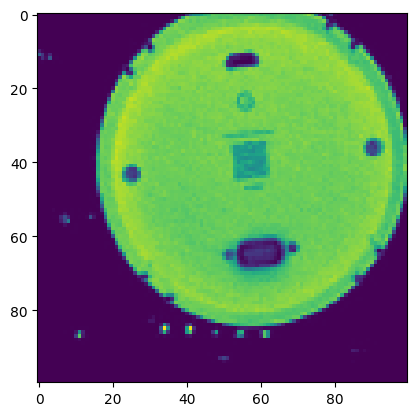

In [67]:
print(y[:10])
plt.imshow(X[0])

In [68]:
# shuffle
X,y = shuffle(X,y)

In [69]:
X = np.array(X).reshape(len(X),-1)
# norm
X = X/255.0
y = np.array(y)

In [70]:
print(X.shape)
print(y.shape)

(52000, 10000)
(52000,)


In [71]:
# split
X_train, X_val, y_train, y_val = train_test_split(X,y)
print("X_train: ",X_train.shape)
print("X_val: ",X_val.shape)
print("y_train: ",y_train.shape)
print("y_val: ",y_val.shape)

X_train:  (39000, 10000)
X_val:  (13000, 10000)
y_train:  (39000,)
y_val:  (13000,)


In [72]:
svc = SVC(kernel='linear',gamma='auto')
svc.fit(X_train, y_train)

SVC(gamma='auto', kernel='linear')

In [73]:
y2 = svc.predict(X_val)

In [74]:
# calc accuracy
print("Accuracy on validation dataset is",accuracy_score(y_val,y2))

Accuracy on validation dataset is 0.9566923076923077


In [75]:
print("Accuracy on validation dataset is")
print(classification_report(y_val,y2))

Accuracy on validation dataset is
              precision    recall  f1-score   support

           1       0.95      0.92      0.93       544
           2       0.97      0.98      0.98       496
           3       0.86      0.96      0.91       511
           4       0.87      0.94      0.90       489
           5       0.96      0.97      0.97       510
           6       0.98      0.98      0.98       464
           7       0.97      0.98      0.98       505
           8       0.97      0.95      0.96       481
           9       1.00      1.00      1.00       484
          10       0.92      0.90      0.91       463
          11       0.98      0.98      0.98       468
          12       0.99      1.00      1.00       523
          13       0.99      0.96      0.97       523
          14       0.95      0.99      0.97       509
          15       0.97      0.96      0.96       483
          16       0.99      0.97      0.98       488
          17       1.00      0.97      0.99    

In [76]:
# save the model to disk
filename = 'ppocr/obj_cla_2000.sav'
pickle.dump(svc, open(filename, 'wb'))

Even when flatten length of new income data does not equal, model still work

In [13]:
# load model
loaded_model = pickle.load(open("ppocr/obj_cla_2000.sav", 'rb'))

Text(0.5, 1.0, 'pred: Google TV Remote\n(Google TV Remote)')

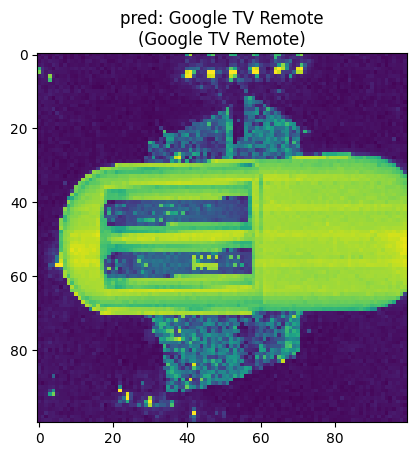

In [15]:
# random test
IMG_SIZE=100
path = 'samples'
imgs = os.listdir(path)
i = random.choice(imgs)
img = cv2.imread(os.path.join(path,i),0)
img = cv2.resize(img,(IMG_SIZE,IMG_SIZE))
plt.imshow(img)
img = img/255.0
img = img.reshape(1,-1)
y= loaded_model.predict(img)
plt.title("pred: " + dic[int(i.strip('.jpg'))] +"\n(" + dic[int(y)] + ")")

In [16]:
# batch test
path = 'test'
preds = []
ground_truth = []

#for l in range(1,len((labels))+1):
for l in range(1,len(labels)+1):
    label = str(l)
    imgs = os.listdir(os.path.join(path,label))
    print("testing label: ",label)
    
    for i in tqdm(imgs):
        i = os.path.join(path,label,i)
        img = cv2.imread(i,0)
        img = cv2.resize(img,(IMG_SIZE,IMG_SIZE))
        img = img/255.0
        img = img.reshape(1,-1)
        preds.append(int(loaded_model.predict(img))) # collect pred
        ground_truth.append(int(label)) # collect ground truth
    

testing label:  1


100%|███████████████████████████████████████| 1000/1000 [02:38<00:00,  6.29it/s]


testing label:  2


100%|███████████████████████████████████████| 1000/1000 [02:38<00:00,  6.32it/s]


testing label:  3


...

100%|███████████████████████████████████████| 1000/1000 [02:39<00:00,  6.26it/s]


testing label:  25


100%|███████████████████████████████████████| 1000/1000 [02:36<00:00,  6.37it/s]


testing label:  26


100%|███████████████████████████████████████| 1000/1000 [03:11<00:00,  5.23it/s]


In [17]:
# calc accuracy
print("Accuracy valid on ",accuracy_score(ground_truth,preds))

Accuracy valid on  0.94


In [18]:
path = "samples"
imgs = os.listdir(path)
imgs = [img for img in imgs if img != 'files.txt']
for i in imgs:
    img = cv2.imread(os.path.join(path,i),0)
    img = cv2.resize(img,(IMG_SIZE,IMG_SIZE))
    img = img/255.0
    img = img.reshape(1,-1)
    pred = int(loaded_model.predict(img))
    label = int(i.strip('.jpg'))
    print(i,"pred: ",label == pred)

15.jpg pred:  True
8.jpg pred:  True
13.jpg pred:  True
19.jpg pred:  True
17.jpg pred:  True
24.jpg pred:  True
3.jpg pred:  True
25.jpg pred:  True
11.jpg pred:  True
23.jpg pred:  True
20.jpg pred:  True
1.jpg pred:  True
18.jpg pred:  True
7.jpg pred:  True
22.jpg pred:  True
14.jpg pred:  True
9.jpg pred:  True
5.jpg pred:  True
16.jpg pred:  True
21.jpg pred:  True
6.jpg pred:  True
2.jpg pred:  True
12.jpg pred:  True
10.jpg pred:  True
4.jpg pred:  True
26.jpg pred:  True
